<a href="https://colab.research.google.com/github/mauriciodev/progcart/blob/main/aulas/jupyter/sentinel_spectral_library.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt

[USGS Spectral Library](https://www.sciencebase.gov/catalog/item/586e8c88e4b0f5ce109fccae)

In [2]:
!wget -O library.zip https://www.sciencebase.gov/catalog/file/get/586e8c88e4b0f5ce109fccae?f=__disk__b4%2Fc4%2Ffd%2Fb4c4fdcbfcda3a1d8bdf8d9823278349b3b294e2

--2026-09-15 01:11:39--  https://www.sciencebase.gov/catalog/file/get/586e8c88e4b0f5ce109fccae?f=__disk__b4%2Fc4%2Ffd%2Fb4c4fdcbfcda3a1d8bdf8d9823278349b3b294e2
Resolving www.sciencebase.gov (www.sciencebase.gov)... 172.65.90.27, 172.65.90.26, 172.65.90.25, ...
Connecting to www.sciencebase.gov (www.sciencebase.gov)|172.65.90.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1456919 (1.4M) [application/zip]
Saving to: ‘library.zip’

library.zip         100%[===================>]   1.39M  3.07MB/s    in 0.5s    

2026-09-15 01:11:39 (3.07 MB/s) - ‘library.zip’ saved [1456919/1456919]



In [3]:
!unzip -q library.zip

In [4]:
import os
import pandas as pd
import glob

base_dir = 'ASCIIdata_splib07b_rsSentinel2/'
# Find all text files within any directory starting with 'Chapter' inside the base_dir
txt_files = glob.glob(os.path.join(base_dir, 'Chapter*', '*.txt'))

all_data_columns = [] # Dictionary to store each file's data as a list

header = ['folder', "filename"] + ["B" + str(i) for i in range(1, 14)]

if not txt_files:
    print(f"No .txt files found in directories starting with 'Chapter' under {base_dir}")
else:
    for file_path in txt_files:
        try:
            # Extract filename without extension to use as column name
            file_name = os.path.basename(file_path)[:-4]
            parent_folder = os.path.basename(os.path.dirname(file_path))
            #file_name = f"{parent_folder}_{file_name}"

            # Read the first 15 lines as a single column.
            # squeeze=True will return a Series if there's only one column.
            with open(file_path) as f:
                series_list = f.readlines()[1:]
            #series_data = pd.read_csv(file_path, header=None, nrows=14, skiprows=1)
            series_list = [float(x) for x in series_list]
            if len(series_list) == 13:
                all_data_columns.append([parent_folder, file_name, *series_list]) #data.tolist()
            else:
                print(f"Warning: File {file_path} did not contain 15 lines of data or was not a single column. Skipping.")

        except Exception as e:
            print(f"Error reading file {file_path}: {e}")

# Create a DataFrame from the collected data
# Each key in all_data_columns becomes a column name, and its value (list) becomes the column's data.
if all_data_columns:
    df = pd.DataFrame(all_data_columns)
    df.columns = header
    df.replace(df['B1'].min(),0, inplace=True)
    print("Successfully created DataFrame with data from multiple files. Here's a preview:")
    print(df.head())
    print("\nDataFrame Information:")
    df.info()
else:
    print("No valid data collected to form a DataFrame.")

Successfully created DataFrame with data from multiple files. Here's a preview:
                      folder  \
0  ChapterS_SoilsAndMixtures   
1  ChapterS_SoilsAndMixtures   
2  ChapterS_SoilsAndMixtures   
3  ChapterS_SoilsAndMixtures   
4  ChapterS_SoilsAndMixtures   

                                            filename        B1        B2  \
0       S07SNTL2_Basalt_weathered_BR93-43_BECKb_AREF  0.101211  0.114943   
1   S07SNTL2_Alun.33+Kaol.33+Musc.33_AMX2_BECKa_AREF  0.520187  0.577729   
2    S07SNTL2_Magnesite+Hydromag_HS47.1B_ASDFRa_AREF  0.881418  0.902541   
3    S07SNTL2_Halloysite+Kaolinite_CM29_NIC4aaa_RREF  0.000000  0.000000   
4  S07SNTL2_Chlorite.33+Epidot.67_GDS318_ASDFRa_AREF  0.086430  0.116359   

         B3        B4        B5        B6        B7        B8        B9  \
0  0.131275  0.148039  0.158212  0.164361  0.164616  0.161236  0.158620   
1  0.646587  0.727347  0.747611  0.760212  0.766562  0.771462  0.774309   
2  0.912605  0.940591  0.945167  0.947250  0.

In [21]:
import ipywidgets as widgets
from IPython.display import display

# Get unique folder names for the first dropdown
unique_folders = df['folder'].unique().tolist()

# Create the first combobox for folder selection
folder_dropdown = widgets.Combobox(
    placeholder='Choose Folder',
    options=unique_folders,
    description='Folder:',
    ensure_option=True,
    disabled=False
)

# Create the second combobox for filename selection (initially empty)
filename_dropdown = widgets.Combobox(
    placeholder='Choose Filename',
    options=[],
    description='Filename:',
    ensure_option=True,
    disabled=False
)

# Function to update the filename dropdown based on the selected folder
def update_filename_dropdown(change):
    selected_folder = change.new
    if selected_folder:
        filtered_df = df[df['folder'] == selected_folder]
        unique_filenames = filtered_df['filename'].unique().tolist()
        filename_dropdown.options = unique_filenames
    else:
        filename_dropdown.options = []
        filename_dropdown.value = ''

# Observe changes in the folder dropdown to update the filename dropdown
folder_dropdown.observe(update_filename_dropdown, names='value')

# Function to update the plot based on selected folder and filename
def update_plot(folder_name, file_name):
    plt.figure(figsize=(12, 7))
    if folder_name and file_name:
        # Filter DataFrame for the selected folder and filename
        plot_data = df[(df['folder'] == folder_name) & (df['filename'] == file_name)]

        if not plot_data.empty:
            b_columns = [col for col in df.columns if col.startswith('B')]
            # Plot the spectral data for the selected row
            plt.plot(b_columns, plot_data.iloc[0][b_columns], marker='o', linestyle='-')
            plt.title(f'Spectral Data for {file_name} in {folder_name}')
            plt.xlabel('Band Number')
            plt.ylabel('Reflectance Value')
        else:
            plt.title(f'No data found for {file_name} in {folder_name}')
    else:
        plt.title('Select a folder and filename to view spectral data')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Initialize the filename dropdown with options from the first folder (if available)
#if unique_folders:
#    folder_dropdown.value = unique_folders[0] # This will trigger update_filename_dropdown

# Create the interactive plot widget
interactive_plot_widget = widgets.interactive(update_plot, folder_name=folder_dropdown, file_name=filename_dropdown)

# Display the widgets
display(interactive_plot_widget)

interactive(children=(Combobox(value='', description='Folder:', ensure_option=True, options=('ChapterS_SoilsAn…

NameError: name 'filtered_df' is not defined

In [5]:
veg_df = df[df['folder'] == 'ChapterV_Vegetation']

# Select 5 random filenames from veg_df and store them in a list
random_filenames = veg_df['filename'].sample(n=5, random_state=42).tolist()
print("5 Random Filenames:")
print(random_filenames)

5 Random Filenames:
['S07SNTL2_Marsh_SPPA55%...a_CRMS326v02_ASDFRa_AREF', 'S07SNTL2_Rangeland_C03-027_S27%_G19%_ASDFRa_AREF', 'S07SNTL2_Rangeland_L02-060_S00%_G13%_ASDFRa_AREF', 'S07SNTL2_Rangeland_C04-204_S24%_G06%_ASDFRa_AREF', 'S07SNTL2_Rangeland_C04-236_S20%_G18%_ASDFRa_AREF']


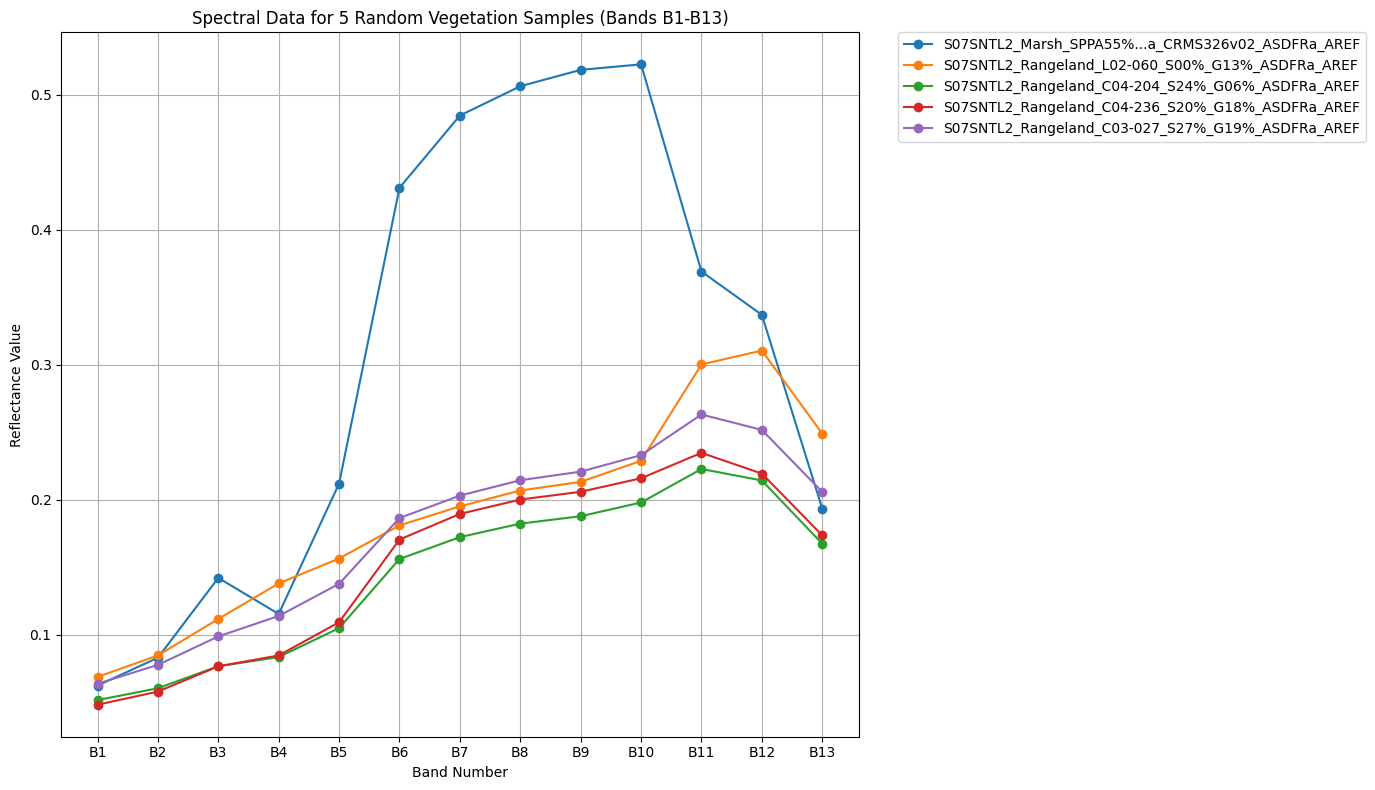

In [6]:
b_columns = [col for col in veg_df.columns if col.startswith('B')]

plt.figure(figsize=(14, 8))

# Filter veg_df to include only the random_filenames
filtered_veg_df = veg_df[veg_df['filename'].isin(random_filenames)]

# Iterate through each row of the filtered veg_df to plot and label
for index, row in filtered_veg_df.iterrows():
    plt.plot(b_columns, row[b_columns], marker='o', linestyle='-', label=row['filename'])

plt.title('Spectral Data for 5 Random Vegetation Samples (Bands B1-B13)')
plt.xlabel('Band Number')
plt.ylabel('Reflectance Value')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Place legend outside the plot
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [7]:
!cat /content/ASCIIdata_splib07b_rsSentinel2/ChapterS_SoilsAndMixtures/S07SNTL2_Halloysite+Kaolinite_CM29_NIC4aaa_RREF.txt

S07SNTL2 Record=4010: Halloysite+Kaolinite CM29   NIC4aaa RREF
-1.2300000e+034
-1.2300000e+034
-1.2300000e+034
-1.2300000e+034
-1.2300000e+034
-1.2300000e+034
-1.2300000e+034
-1.2300000e+034
-1.2300000e+034
-1.2300000e+034
 6.2234700e-001
 6.2589645e-001
 3.7153593e-001
